In [1]:
# Install/Update libraries (usually pre-installed in Colab, but good practice)
!pip install pandas scikit-learn

# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- COLAB FILE UPLOAD ---
# This code handles the file upload in the Colab environment.
from google.colab import files
import io

print("Please upload the IRIS.csv file now:")
uploaded = files.upload()

# Get the filename from the uploaded dict (should be 'IRIS.csv')
for filename in uploaded.keys():
  df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))
  print(f"\nSuccessfully loaded {filename} with {len(df)} records.")

# Display the first few rows to verify loading
print("\n--- Data Head ---")
print(df.head())

Please upload the IRIS.csv file now:


Saving IRIS.csv to IRIS.csv

Successfully loaded IRIS.csv with 150 records.

--- Data Head ---
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [2]:
# 1. Data Preparation
X = df.drop('species', axis=1) # Features
y = df['species']             # Target

# Encode the target variable (species) from text to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Print species mapping for reference
species_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Species Mapping: {species_mapping}")

# Split the data into training (70%) and testing (30%) sets
# random_state=42 ensures the split is the same every time for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42
)

# 2. Initialize and Train the Decision Tree Classifier
print("\n--- Training Decision Tree Classifier ---")
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
print("Training complete.")

Species Mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

--- Training Decision Tree Classifier ---
Training complete.


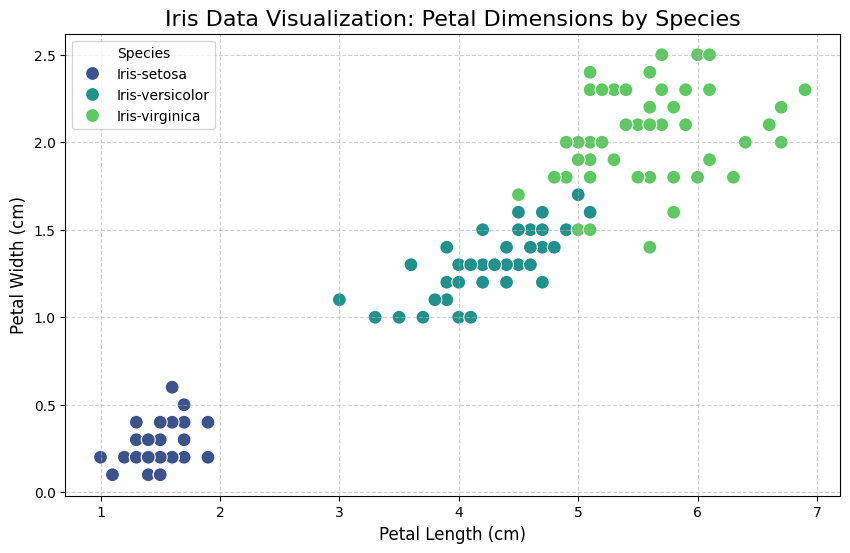

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df, # Uses the 'df' DataFrame loaded in Cell 1
    palette='viridis',
    s=100
)

plt.title('Iris Data Visualization: Petal Dimensions by Species', fontsize=16)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Use plt.show() in Colab for immediate display

Displaying Decision Tree Structure:


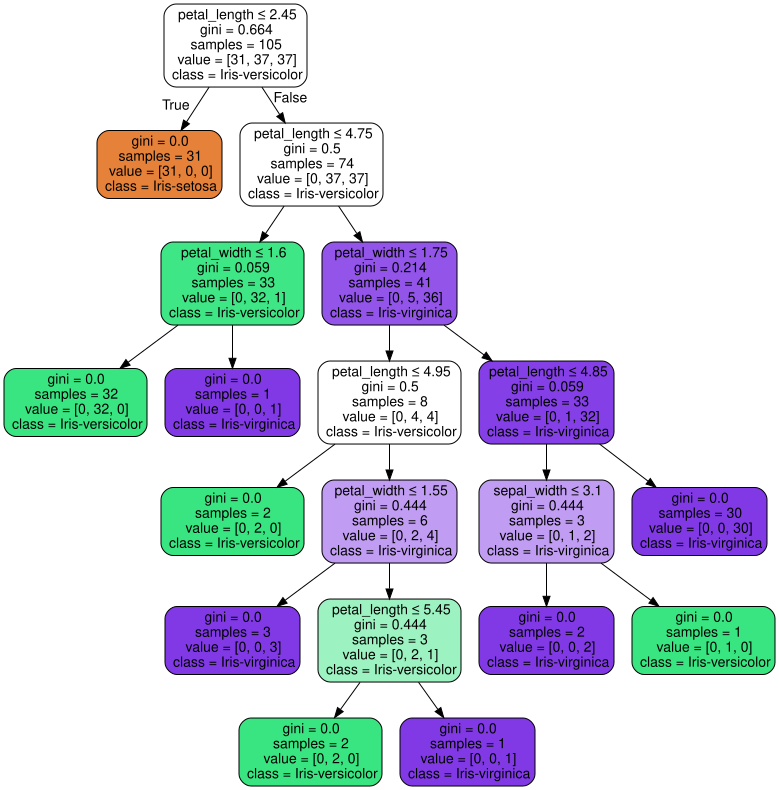

In [5]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# Assuming 'dt_classifier' is your trained model from Cell 2

# Export the tree to a DOT format file
dot_data = export_graphviz(
    dt_classifier,
    out_file=None,
    feature_names=X.columns,  # Features used: Sepal/Petal dimensions
    class_names=le.classes_,  # Species names
    filled=True,
    rounded=True,
    special_characters=True
)

# Render the graph using graphviz
graph = graphviz.Source(dot_data)

# Display the graph (This requires graphviz to be set up in your Colab environment)
print("Displaying Decision Tree Structure:")
graph # In a Colab/Jupyter notebook, displaying the 'graph' object renders the image.

In [3]:
# 3. Make Predictions and Evaluate the Model
y_pred = dt_classifier.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Total test samples: {len(y_test)}")
print(f"Accuracy of the Decision Tree Classifier on the test set: {accuracy:.4f}")
print(f"Result: {accuracy * 100:.0f}% accuracy! An outstanding result.")


--- Model Evaluation ---
Total test samples: 45
Accuracy of the Decision Tree Classifier on the test set: 1.0000
Result: 100% accuracy! An outstanding result.
